In [1]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np
import librosa
import random

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline

from transformers import Resampler, MelSpectrogramTransformer, SpectrogramPadder, FlattenTransformer, FeatureExtractor, NoiseAdder

from config import TEST_SIZE, SEED, SAMPLING_RATE, N_MELS, N_FFT
from utils import plot_mel_spectrogram_from_dB, save_mel_images

# Procesamiento de ventanas temporales

In [2]:
df = pd.read_csv('./data_preprocesada/ventanas/labels.csv')

Buscamos identificar cualquier anormalidad en los ciclos, por ejemplo crepitaciones (_crackles_) y sibilancias (_wheezes_). Para esto combinamos las etiquetas en para lograr una binaria.

In [3]:
df.head()

,filename,label
0,101_1b1_Al_sc_Meditron_win000.wav,normal
1,101_1b1_Al_sc_Meditron_win001.wav,normal
2,101_1b1_Al_sc_Meditron_win002.wav,normal
3,101_1b1_Al_sc_Meditron_win003.wav,normal
4,101_1b1_Al_sc_Meditron_win004.wav,normal


In [4]:
df.label.value_counts()

label
normal     2433
crackle    1410
wheeze      672
both        493
Name: count, dtype: int64

In [5]:
df['label'] = df['label'].map({'normal': 0, 'wheeze': 1, 'crackle': 1, 'both': 1})

In [6]:
df.label.value_counts()

label
1    2575
0    2433
Name: count, dtype: int64

## Filtrado (opcional)

In [7]:
df = df[df['filename'].str.contains('AKGC417L')].copy()

In [8]:
df.label.value_counts()

label
1    1888
0    1342
Name: count, dtype: int64

## Procesados

Definimos un nombre para el dataset y creamos una carpeta final

In [9]:
dataset = 'mic_aug'

os.makedirs(f'./data_procesada/ventanas/{dataset}', exist_ok=True)

El pipeline recibe una ruta, tenemos que construir un conjunto con todas las rutas y dividir en conjuntos de train y test.

In [10]:
X = df['filename'].tolist()
y = df['label'].tolist()

X = [os.path.join('./data_preprocesada/ventanas/', path) for path in X]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

Cuando se dividieron las ventanas pueden haber quedado audios muy cortos (la ventana final).

Para identificarlos y eliminarlos simulamos el armado de los espectrogramas.

In [11]:
pipeline_temp = Pipeline([
    ('resampler', Resampler()),
    ('melspec', MelSpectrogramTransformer(hop_length=128))
])

X_proc = pipeline_temp.fit_transform(X_train)

Si hubo un warning entonces hay audios demasiado cortos para el n_ftt usado

In [12]:
import warnings

short_indices = []

for i, x in enumerate(X_train):
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        _ = pipeline_temp.transform([x])
        if any("n_fft" in str(warn.message) for warn in w):
            short_indices.append(i)

print("Audios demasiado cortos:", short_indices)

Audios demasiado cortos: []


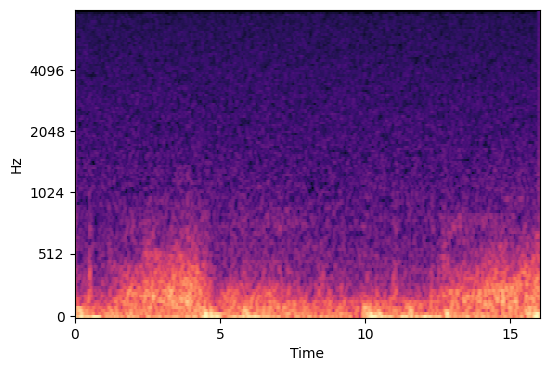

In [13]:
plot_mel_spectrogram_from_dB(X_proc[13].reshape(128, -1))

In [14]:
for i in short_indices:
    print(f'Index: {i}, Label: {y_train[i]}')

Eliminamos las ventanas molestas

In [15]:
for index in sorted(short_indices, reverse=True):
    del X_train[index]
    del y_train[index]

Repetimos en el conjunto de testeo

In [16]:
X_proc = pipeline_temp.fit_transform(X_test)

short_indices = []
for i, x in enumerate(X_test):
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        _ = pipeline_temp.transform([x])
        if any("n_fft" in str(warn.message) for warn in w):
            short_indices.append(i)
print("Audios demasiado cortos en test:", short_indices)

Audios demasiado cortos en test: []


In [17]:
# check labels for short audios
for i in short_indices:
    print(f'Index: {i}, Label: {y_test[i]}')

In [18]:
for index in sorted(short_indices, reverse=True):
    del X_test[index]
    del y_test[index]

In [19]:
X_proc[0].shape

(128, 501)

### Augmentation
Traemos los paths de los audios de ruido real

Esta parte se ejecutá sólo si el nombre del dataset contiene 'aug'.

In [20]:
noise_paths = os.listdir('./dataset/ruido/train')
noise_paths = [os.path.join('./dataset/ruido/train', path) for path in noise_paths]

test_noise_paths = os.listdir('./dataset/ruido/test')
test_noise_paths = [os.path.join('./dataset/ruido/test', path) for path in test_noise_paths]

El primer paso del pipeline es el resampleo de los audios, se pasan a 16 kHz

In [21]:
random.seed(SEED)

resampler = Resampler()
X_train_resampled = resampler.fit_transform(X_train)
X_test_resampled = resampler.transform(X_test)

Para agregar el ruido instanciamos varios agragadores de ruido.
+ Ruido blanco
+ Ruido real débil
+ Ruido real fuerte
+ Ruido real moderado

In [22]:
if 'aug' in dataset:
    # instanciamos los distintos NoiseAdders
    white_noise_adder = NoiseAdder(noise_files=[], mode='white', snr_min=5, snr_max=10, random_state=SEED)
    real_noise_adder_weak = NoiseAdder(noise_files=noise_paths, mode='pool', snr_min=8, snr_max=10, random_state=SEED)
    real_noise_adder = NoiseAdder(noise_files=noise_paths, mode='pool', snr_min=3, snr_max=7, random_state=SEED)
    real_noise_adder_strong = NoiseAdder(noise_files=noise_paths, mode='pool', snr_min=1, snr_max=2, random_state=SEED)

    white_noise_adder_test = NoiseAdder(noise_files=[], mode='white', snr_min=5, snr_max=10, random_state=SEED)
    real_noise_adder_test_weak = NoiseAdder(noise_files=test_noise_paths, mode='pool', snr_min=8, snr_max=10, random_state=SEED)
    real_noise_adder_test = NoiseAdder(noise_files=test_noise_paths, mode='pool', snr_min=3, snr_max=7, random_state=SEED)
    real_noise_adder_test_strong = NoiseAdder(noise_files=test_noise_paths, mode='pool', snr_min=1, snr_max=2, random_state=SEED)

    # agregamos ruido a los datos de entrenamiento y prueba
    X_train_white = white_noise_adder.transform(X_train_resampled)
    X_train_real_weak = real_noise_adder_weak.transform(X_train_resampled)
    X_train_real  = real_noise_adder.transform(X_train_resampled)
    X_train_real_strong = real_noise_adder_strong.transform(X_train_resampled)

    X_test_white = white_noise_adder_test.transform(X_test_resampled)
    X_test_real_weak = real_noise_adder_test_weak.transform(X_test_resampled)
    X_test_real  = real_noise_adder_test.transform(X_test_resampled)
    X_test_real_strong = real_noise_adder_test_strong.transform(X_test_resampled)

    # combinamos las aumentaciones
    X_train = (
        X_train_white +
        X_train_real_weak +
        X_train_real +
        X_train_real_strong
    )
    y_train = (
        y_train +
        y_train +
        y_train +
        y_train
    )

    X_test = (
        X_test_white +
        X_test_real_weak +
        X_test_real +
        X_test_real_strong
    )
    y_test = (
        y_test +
        y_test +
        y_test +
        y_test
    )

    # mezclamos los datos aumentados
    combined = list(zip(X_train, y_train))
    random.shuffle(combined)
    X_train, y_train = zip(*combined)
    X_train = list(X_train)
    y_train = list(y_train)

else:
    X_train = X_train_resampled
    X_test = X_test_resampled

### Mel espectrograma

Con los datos ya aumentados, vamos a contruir los espectrogramas en escala Mel.

Para esto usamos los transformers:
+ ``MelSpectrogramTransformer``: procesa el audio a una matriz ue representa el espectrgrama Mel.
+ ``SpectrogramPadder``: agrega _padding_ al comienzo y final.
+ `FlattenTransformer`: simplemente aplana la matriz a un vector 1D.

In [23]:
pipeline_melspec = Pipeline([
    # ya estan resampleados
    ('melspec', MelSpectrogramTransformer(hop_length=128)),
    ('padder', SpectrogramPadder(max_length=X_proc[0].shape[1])),
    ('flattener', FlattenTransformer())
])

Transformamos los audios con el pipeline definido.

In [ ]:
X_train_melspecs = pipeline_melspec.fit_transform(X_train)
X_test_melspecs = pipeline_melspec.transform(X_test)

In [ ]:
print(X_train_melspecs.shape, X_test_melspecs.shape)

(10336, 64128) (2584, 64128)


Observamos los espectrogramas resultantes

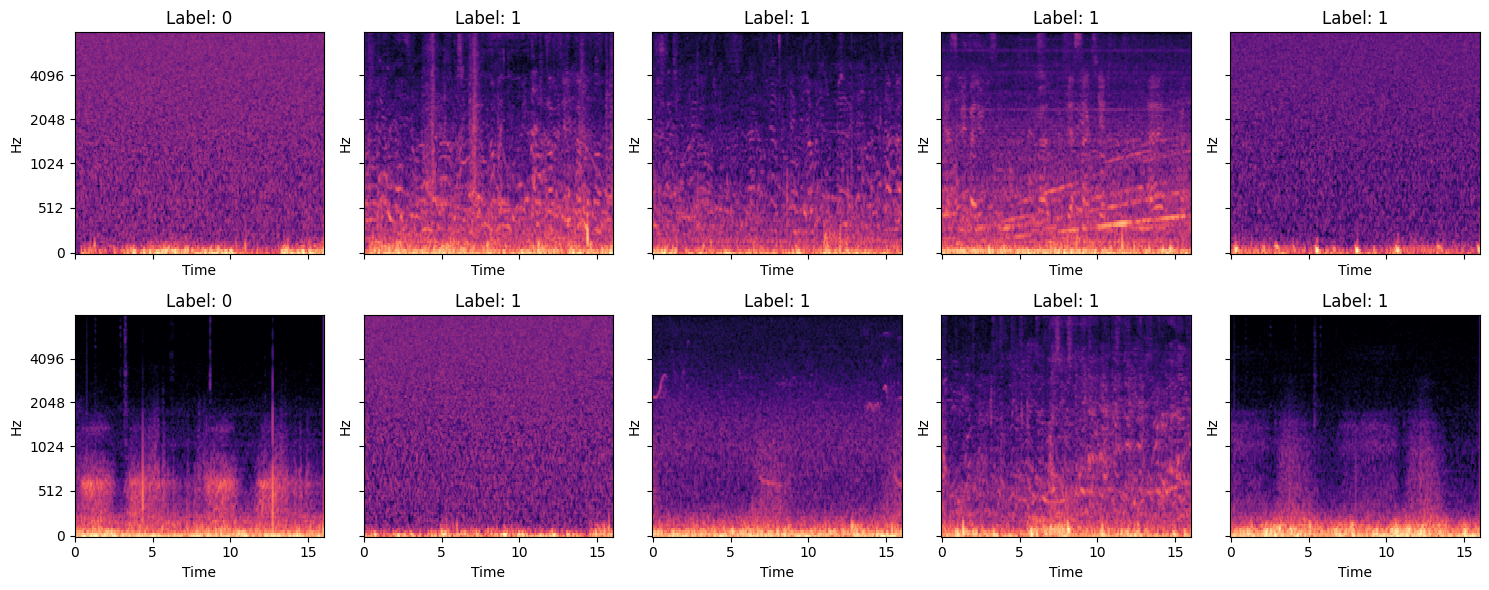

In [ ]:
fig, axs = plt.subplots(2, 5, figsize=(15,6), sharey=True, sharex=True)
for i in range(10):
    ax = axs[i//5, i%5]
    img = librosa.display.specshow(X_train_melspecs[i].reshape(128, -1), sr=SAMPLING_RATE, x_axis='time', y_axis='mel', n_fft=N_FFT, ax=ax, cmap='magma')
    ax.set_title(f'Label: {y_train[i]}')
plt.tight_layout();

Guardamos las matrices

In [ ]:
np.savez_compressed(
    f'./data_procesada/ventanas/{dataset}/train_melspectrogram.npz',
    X=X_train_melspecs,
    y=y_train
)

np.savez_compressed(
    f'./data_procesada/ventanas/{dataset}/test_melspectrogram.npz',
    X=X_test_melspecs,
    y=y_test
)

#### Imagenes

También generamos imágenes con las matrices para entrenar la CNN.

Para las CNN se necesita un conjunto de validacion, es mejor definirlo ahora asi es consistente.

In [ ]:
X_train_melspecs, X_val_melspecs, y_train_imgs, y_val = train_test_split(
    X_train_melspecs, y_train, test_size=0.2, random_state=SEED, stratify=y_train
)

In [ ]:
save_mel_images(X_train_melspecs.reshape(-1, 128, 501), y_train_imgs, 'imgs/train', dataset, preproc='ventanas')
save_mel_images(X_val_melspecs.reshape(-1, 128, 501), y_val, 'imgs/val', dataset, preproc='ventanas')
save_mel_images(X_test_melspecs.reshape(-1, 128, 501), y_test, 'imgs/test', dataset, preproc='ventanas')

### Atributos de audio

Para este procesamiento sólo necesitamos un transformer, además del resampler:
+ `FeatureExtractor`: extrae todos los atributos considerados para la clasificación

In [ ]:
pipeline_feature_extraction = Pipeline([
    # ya estan resampleados
    ('feature_extractor', FeatureExtractor(hop_length=128))
])

In [ ]:
X_train_features = pipeline_feature_extraction.fit_transform(X_train)

In [ ]:
X_test_features = pipeline_feature_extraction.transform(X_test)

c:\Users\nazar\Clasificador-Respiracion\venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [ ]:
np.savez_compressed(
    f'./data_procesada/ventanas/{dataset}/train_features.npz',
    X=X_train_features,
    y=y_train
)

np.savez_compressed(
    f'./data_procesada/ventanas/{dataset}/test_features.npz',
    X=X_test_features,
    y=y_test
)